<a href="https://colab.research.google.com/github/RubenAndreeB/TelecomX_AluraLatam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracción(E - Extract)

✅ Cargar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

In [29]:
import pandas as pd
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Nos encontramos con tres columnas que cuentan con diccionarios que hacen referencia a su columna, por lo que necesitamos solucionar ese inconveniente.

In [30]:
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

for columna in columnas_anidadas:
    df_anidado = pd.json_normalize(df[columna])
    df = pd.concat([df, df_anidado], axis=1)
    df = df.drop(columna, axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 Transformación (T - Transform)

## Conoce el conjunto de datos
✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [31]:
# Exploramos las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Este es el diccionario de datos:
- customerID: número de identificación único de cada cliente
- Churn: si el cliente dejó o no la empresa
- gender: género (masculino y femenino)
- SeniorCitizen: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- Partner: si el cliente tiene o no una pareja
- Dependents: si el cliente tiene o no dependientes
- tenure: meses de contrato del cliente
- PhoneService: suscripción al servicio telefónico
- MultipleLines: suscripción a más de una línea telefónica
- InternetService: suscripción a un proveedor de internet
- OnlineSecurity: suscripción adicional de seguridad en línea
- OnlineBackup: suscripción adicional de respaldo en línea
- DeviceProtection: suscripción adicional de protección del dispositivo
- TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
- StreamingTV: suscripción de televisión por cable
- StreamingMovies: suscripción de streaming de películas
- Contract: tipo de contrato
- PaperlessBilling: si el cliente prefiere recibir la factura en línea
- PaymentMethod: forma de pago
- Charges.Monthly: total de todos los servicios del cliente por mes
- Charges.Total: total gastado por el cliente

Viendo eso, el unico que esta mal, es el ultimo Charges.Total, ya que son valores numericos de gastos.

No nos funciona, porque tenemos strings con ' ' por lo que primero debemos limpiar esos espacios vacios.

In [32]:
df['Charges.Total'] = df['Charges.Total'].str.replace (' ', '0')
df['Charges.Total'] = df['Charges.Total'].astype(np.float64)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Comprobación de incoherencias en los datos

In [34]:
print(f'Existen {len(df.customerID.unique())} customerID diferentes.')

for col in df.columns:
  print(f'La columna {col} cuenta con las siguientes opciones: {df[col].unique()}')

Existen 7267 customerID diferentes.
La columna customerID cuenta con las siguientes opciones: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
La columna Churn cuenta con las siguientes opciones: ['No' 'Yes' '']
La columna gender cuenta con las siguientes opciones: ['Female' 'Male']
La columna SeniorCitizen cuenta con las siguientes opciones: [0 1]
La columna Partner cuenta con las siguientes opciones: ['Yes' 'No']
La columna Dependents cuenta con las siguientes opciones: ['Yes' 'No']
La columna tenure cuenta con las siguientes opciones: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
La columna PhoneService cuenta con las siguientes opciones: ['Yes' 'No']
La columna MultipleLines cuenta con las siguientes opciones: ['No' 'Yes' 'No phone service']
La columna InternetService cue

Podemos observar que nos encontramos con las colmnas con diferentes opciones, por ejemplo Churn, tiene como opcion '' cuando eso no significa nada, por lo que debemos corregir.

In [35]:
df['Churn'] = df['Churn'].replace('', 'No')
df['MultipleLines'] = df['MultipleLines'].str.replace('No phone service', 'No')

columnas = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for columna in columnas:
  df[columna] = df[columna].replace('No internet service', 'No')

for col in df.columns:
  print(f'La columna {col} cuenta con las siguientes opciones: {df[col].unique()}')

La columna customerID cuenta con las siguientes opciones: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
La columna Churn cuenta con las siguientes opciones: ['No' 'Yes']
La columna gender cuenta con las siguientes opciones: ['Female' 'Male']
La columna SeniorCitizen cuenta con las siguientes opciones: [0 1]
La columna Partner cuenta con las siguientes opciones: ['Yes' 'No']
La columna Dependents cuenta con las siguientes opciones: ['Yes' 'No']
La columna tenure cuenta con las siguientes opciones: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
La columna PhoneService cuenta con las siguientes opciones: ['Yes' 'No']
La columna MultipleLines cuenta con las siguientes opciones: ['No' 'Yes']
La columna InternetService cuenta con las siguientes opciones: ['DSL' 'Fiber optic' 'No'

## Columna de cuentas diarias (Opcional)
Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [39]:
df['Charges.Daily'] = df['Charges.Monthly'] / 30
df['Charges.Daily']

,Charges.Daily
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667



## Estandarización y transformación de datos (opcional)

La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis. Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [40]:
columns_with_yes_no = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for column in columns_with_yes_no:
  df[column] = df[column].str.replace('No', '0')
  df[column] = df[column].str.replace('Yes', '1')
  df[column] = df[column].astype(int)

# 📊 Carga y análisis(L - Load & Analysis)

## Análisis Descriptivo
Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 Consejos:

🔗 [Documentación](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) de DataFrame.describe()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   object 


In [42]:
df.describe()


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Charges.Daily
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Distribución de evasión
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

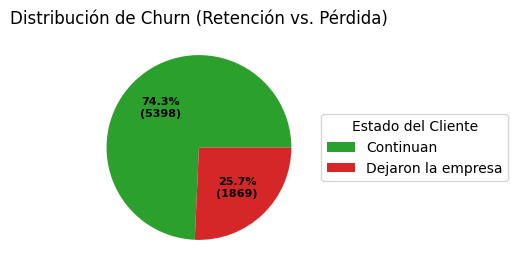

In [78]:
import matplotlib.pyplot as plt

conteos_churn = df['Churn'].value_counts()
data = conteos_churn.values
etiquetas = ['Continuan', 'Dejaron la empresa']
colores = ['#2ca02c', '#d62728'] # Verde para el 0, Rojo para el 1

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

def setformat_porcent_count(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return "{:.1f}%\n({:d})".format(pct, absolute)

wedges, texts, autotexts = ax.pie(
    data,
    autopct=lambda pct: setformat_porcent_count(pct, data),
    textprops=dict(color="black"),
    colors=colores # <--- Aquí aplicamos los colores
)

ax.legend(
    wedges,
    etiquetas,
    title="Estado del Cliente",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Distribución de Churn (Retención vs. Pérdida)", loc='center')

plt.show()

## Recuento de evasión por variables categóricas
Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

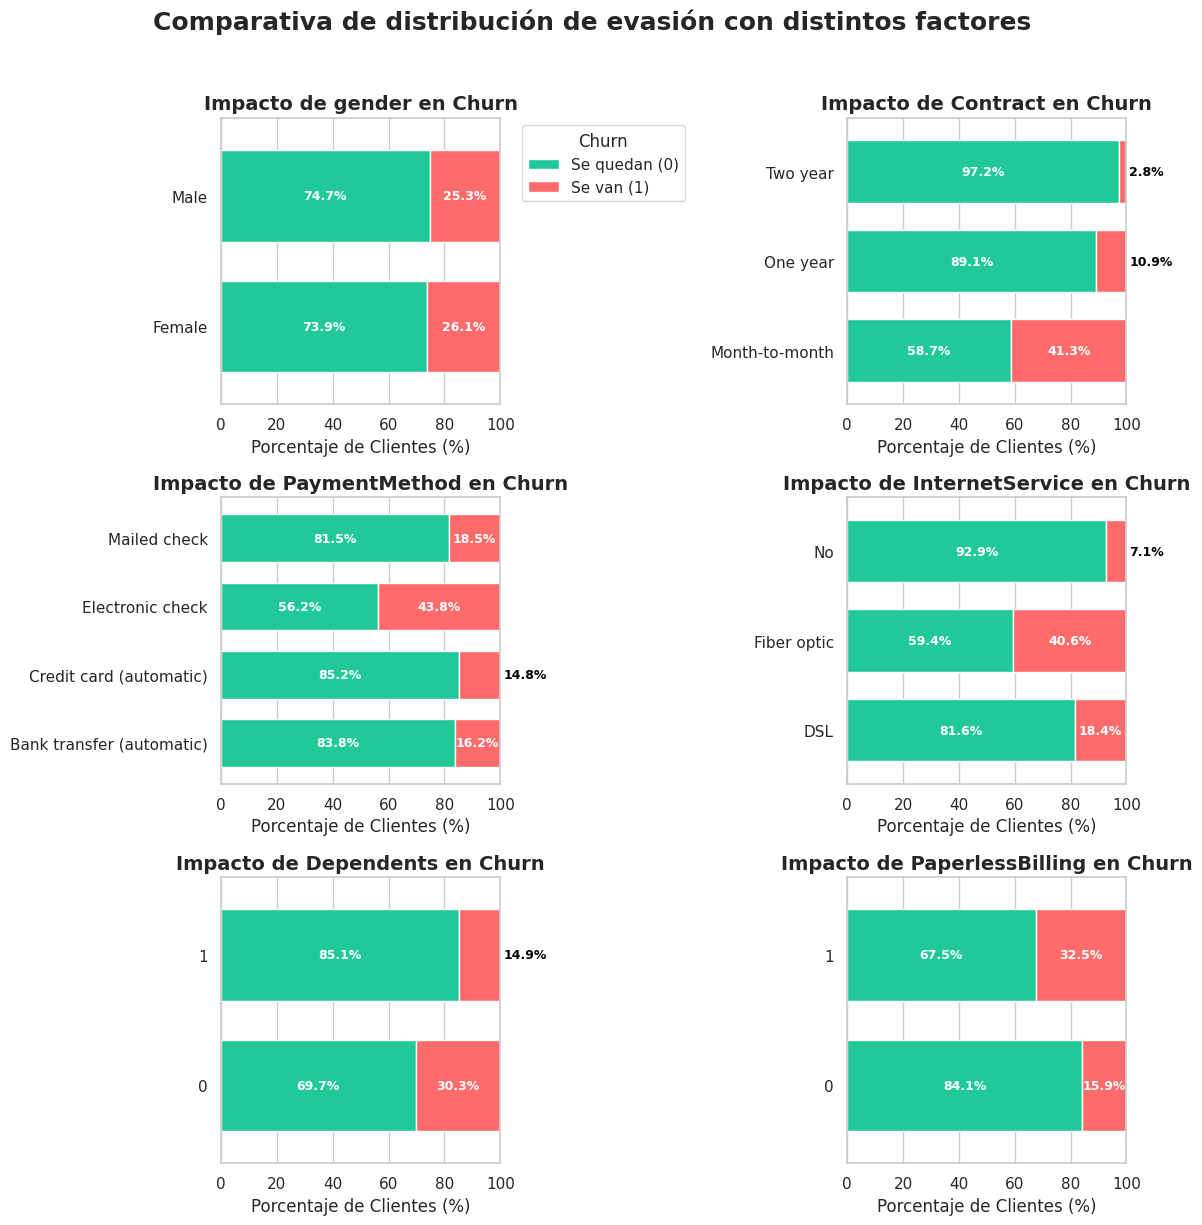

In [103]:
import seaborn as sns

sns.set_theme(style="whitegrid")
columnas_explorar = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'Dependents', 'PaperlessBilling']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()

colores_modernos = ['#20c997', '#ff6b6b']

for i, columna in enumerate(columnas_explorar):
    tabla_porcentajes = pd.crosstab(df[columna], df['Churn'], normalize='index') * 100

    tabla_porcentajes.plot(
        kind='barh',
        stacked=True,
        ax=axes[i],
        color=colores_modernos,
        edgecolor='white',
        width=0.7
    )

    axes[i].set_title(f'Impacto de {columna} en Churn', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Porcentaje de Clientes (%)')

    for container in axes[i].containers:
        for bar in container:
            width = bar.get_width()

            if width < 15:
                axes[i].text(
                    bar.get_x() + width + 1,
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left',
                    va='center',
                    color='black',
                    fontweight='bold',
                    fontsize=9
                )
            else:
                axes[i].text(
                    bar.get_x() + width/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='center',
                    va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=9
                )

    axes[i].set_xlim(0, 100)

    if i == 0:
        axes[i].legend(title='Churn', labels=['Se quedan (0)', 'Se van (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

fig.suptitle('Comparativa de distribución de evasión con distintos factores', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Churn           0          1
gender                      
Female  73.858575  26.141425
Male    74.693878  25.306122


Churn                   0          1
Contract                            
Month-to-month  58.676654  41.323346
One year        89.071758  10.928242
Two year        97.246127   2.753873


Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.763373  16.236627
Credit card (automatic)    85.204082  14.795918
Electronic check           56.196319  43.803681
Mailed check               81.501502  18.498498


Churn                    0          1
InternetService                      
DSL              81.551447  18.448553
Fiber optic      59.443402  40.556598
No               92.852625   7.147375


Churn               0          1
Dependents                      
0           69.661817  30.338183
1           85.052728  14.947272


Churn                     0          1
PaperlessBilling                      
0